# Hybrid Convolutional Transformer Network with Sequence Embedding and Bootstrap Resampling

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohitbme23b064/chess-project/chess_tensor.npy
/kaggle/input/datasets/rohitbme23b064/chess-project/chess_scalar.parquet


2026-05-23 08:20:46.763572: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779524446.789680     745 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779524446.798753     745 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779524446.818882     745 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779524446.818900     745 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779524446.818902     745 computation_placer.cc:177] computation placer alr


GPUs Available:

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

Loading dataframe...

Scalar shape: (337981, 21)

Loading tensor...

Tensor shape: (337981, 12, 8, 8)

========== ORIGINAL CLASS COUNTS ==========

label
good          221151
excellent      57825
inaccuracy     28194
mistake        22817
blunder         7994
Name: count, dtype: int64

Performing oversampling...


========== BALANCED CLASS COUNTS ==========

label
good          221151
blunder       221151
excellent     221151
inaccuracy    221151
mistake       221151
Name: count, dtype: int64

Classes:

['blunder' 'excellent' 'good' 'inaccuracy' 'mistake']

Scalar shape:
(1105755, 15)

Train tensor:
(884604, 12, 8, 8)

Test tensor:
(221151, 12, 8, 8)


I0000 00:00:1779524463.986282     745 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779524463.991495     745 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 12, 8, 8)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute (Permute)   │ (None, 8, 8, 12)  │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 8, 8, 32)  │      3,488 │ permute[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 8, 8, 32)  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 8, 8, 64)  │     18,496 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 64)  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 64, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 64, 64)    │      4,096 │ reshape[0][0]     │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     66,368 │ positional_embed… │
│ (MultiHeadAttentio… │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64, 64)    │        128 │ dropout_1[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64, 128)   │      8,320 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64, 128)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64, 64)    │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ dense_1[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     66,368 │ add_1[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ dropout_4[0][0] 

...


Starting training...

Epoch 1/100


I0000 00:00:1779524481.040384     814 service.cc:152] XLA service 0x7dddb000e680 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779524481.040429     814 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779524481.040435     814 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779524483.190966     814 cuda_dnn.cc:529] Loaded cuDNN version 91002


   21/22116 ━━━━━━━━━━━━━━━━━━━━ 3:04 8ms/step - accuracy: 0.2531 - loss: 1.8964 

I0000 00:00:1779524492.920388     814 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


22116/22116 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4738 - loss: 1.2160
Epoch 1: val_accuracy improved from -inf to 0.52986, saving model to /kaggle/working/best_transformer_model.keras
22116/22116 ━━━━━━━━━━━━━━━━━━━━ 179s 7ms/step - accuracy: 0.4739 - loss: 1.2160 - val_accuracy: 0.5299 - val_loss: 1.0781 - learning_rate: 5.0000e-04
Epoch 2/100
22111/22116 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5579 - loss: 1.0329
Epoch 2: val_accuracy improved from 0.52986 to 0.57050, saving model to /kaggle/working/best_transformer_model.keras
22116/22116 ━━━━━━━━━━━━━━━━━━━━ 144s 7ms/step - accuracy: 0.5579 - loss: 1.0329 - val_accuracy: 0.5705 - val_loss: 0.9918 - learning_rate: 5.0000e-04
Epoch 3/100
22114/22116 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5813 - loss: 0.9748
Epoch 3: val_accuracy did not improve from 0.57050
22116/22116 ━━━━━━━━━━━━━━━━━━━━ 144s 6ms/step - accuracy: 0.5813 - loss: 0.9748 - val_accuracy: 0.5704 - val_loss: 0.9896 - learning_rate: 5.0000e-04
Epoc

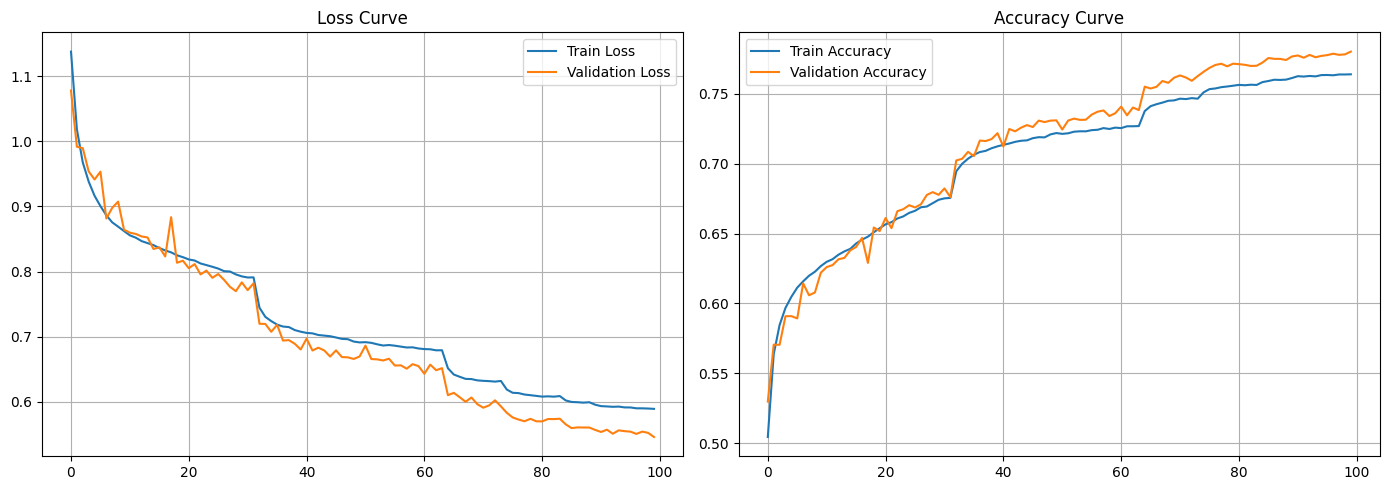


Evaluating model...


Test Accuracy: 78.06%
864/864 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step


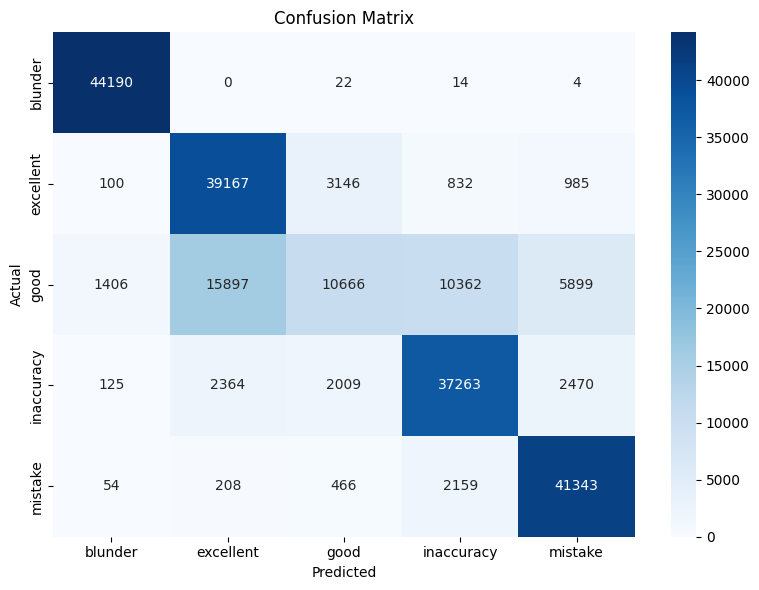


Classification Report:

              precision    recall  f1-score   support

     blunder       0.96      1.00      0.98     44230
   excellent       0.68      0.89      0.77     44230
        good       0.65      0.24      0.35     44230
  inaccuracy       0.74      0.84      0.79     44231
     mistake       0.82      0.93      0.87     44230

    accuracy                           0.78    221151
   macro avg       0.77      0.78      0.75    221151
weighted avg       0.77      0.78      0.75    221151


Random 100 Sample Accuracy: 76.00%

Random Samples:

    move_number          turn  en_passant  halfmove_clock      is_check  \
0     47.000000  1.000000e+00        -1.0    3.000000e+00  9.603676e-10   
1     23.000000  1.000000e+00        -1.0    7.887668e-08  9.603676e-10   
2    121.000000  1.000000e+00        -1.0    1.600000e+01  9.603676e-10   
3     52.000000  1.532653e-08        -1.0    7.887668e-08  9.603676e-10   
4     31.000000  1.000000e+00        -1.0    3.000000e+00

In [ ]:
# ==========================================================
# CHESS HYBRID CNN + TRANSFORMER MODEL
# ==========================================================
# Architecture:
#
# Tensor Input (12x8x8)
#        ↓
# CNN Feature Extraction
#        ↓
# Reshape to Sequence
#        ↓
# Transformer Encoder
#        ↓
# Global Pooling
#        ↓
# Concatenate Scalar Features
#        ↓
# Dense Layers
#        ↓
# Softmax Output
#
# Includes:
# - Oversampling
# - Memory optimization
# - Batch feature handling
# - Model saving
# - Graphs
# - Confusion matrix
# - Classification report
# - Random prediction samples
# ==========================================================

# ==========================================================
# IMPORTS
# ==========================================================

import os
import gc
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils import resample

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

import tensorflow as tf

from tensorflow.keras import (
    layers,
    models,
    regularizers,
    callbacks
)

# ==========================================================
# ENABLE GPU MEMORY GROWTH
# ==========================================================

gpus = tf.config.experimental.list_physical_devices('GPU')

for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

print("\nGPUs Available:\n")
print(gpus)

# ==========================================================
# DATASET PATH
# ==========================================================

base_path = "/kaggle/input/datasets/sachin211104/sachin-chess-project/"

# ==========================================================
# LOAD DATA
# ==========================================================

base_path = "/kaggle/input/datasets/rohitbme23b064/chess-project/"

# ==========================================================
# LOAD DATA
# ==========================================================

print("\nLoading dataframe...\n")

df = pd.read_parquet(
    base_path + "chess_scalar.parquet"
)

print("Scalar shape:", df.shape)

print("\nLoading tensor...\n")

X_tensor = np.load(
    base_path + "chess_tensor.npy",
    mmap_mode='r'
)

print("Tensor shape:", X_tensor.shape)
#-----------------------------------


# ==========================================================
# ORIGINAL CLASS COUNTS
# ==========================================================

print("\n========== ORIGINAL CLASS COUNTS ==========\n")

print(
    df["label"].value_counts()
)

# ==========================================================
# CREATE INDEX
# ==========================================================

df = df.reset_index(drop=True)

df["idx"] = np.arange(len(df))

# ==========================================================
# OVERSAMPLING
# ==========================================================

print("\nPerforming oversampling...\n")

max_count = df["label"].value_counts().max()

balanced_indices = []

for label_name in df["label"].unique():

    class_indices = df[
        df["label"] == label_name
    ]["idx"].values

    oversampled_indices = resample(

        class_indices,

        replace=True,

        n_samples=max_count,

        random_state=42
    )

    balanced_indices.extend(
        oversampled_indices
    )

balanced_indices = np.array(
    balanced_indices
)

np.random.shuffle(
    balanced_indices
)

# ==========================================================
# BUILD BALANCED DATASET
# ==========================================================

df_balanced = df.iloc[
    balanced_indices
].reset_index(drop=True)

# lazy tensor loading
X_tensor_balanced = X_tensor[
    balanced_indices
]

# ==========================================================
# BALANCED COUNTS
# ==========================================================

print("\n========== BALANCED CLASS COUNTS ==========\n")

print(
    df_balanced["label"].value_counts()
)

# ==========================================================
# LABEL ENCODING
# ==========================================================

le = LabelEncoder()

y_encoded = le.fit_transform(
    df_balanced["label"]
)

y = tf.keras.utils.to_categorical(
    y_encoded
)

print("\nClasses:\n")
print(le.classes_)

# ==========================================================
# REMOVE LEAKAGE FEATURES
# ==========================================================

leak_cols = [

    "label",
    "delta",
    "eval",
    "piece_moved",
    "is_capture",
    "gives_check",
    "idx"
]

X_scalar = df_balanced.drop(
    columns=leak_cols
).values

print("\nScalar shape:")
print(X_scalar.shape)

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_tensor_train, X_tensor_test, \
X_scalar_train, X_scalar_test, \
y_train, y_test = train_test_split(

    X_tensor_balanced,
    X_scalar,
    y,

    test_size=0.2,

    random_state=42,

    stratify=np.argmax(y, axis=1)
)

# ==========================================================
# SCALE SCALAR FEATURES
# ==========================================================

scaler = StandardScaler()

X_scalar_train = scaler.fit_transform(
    X_scalar_train
)

X_scalar_test = scaler.transform(
    X_scalar_test
)

# ==========================================================
# MEMORY OPTIMIZATION
# ==========================================================

X_tensor_train = X_tensor_train.astype(
    np.float16
)

X_tensor_test = X_tensor_test.astype(
    np.float16
)

X_scalar_train = X_scalar_train.astype(
    np.float32
)

X_scalar_test = X_scalar_test.astype(
    np.float32
)

# ==========================================================
# LABELS
# ==========================================================

y_train_labels = np.argmax(
    y_train,
    axis=1
)

y_test_labels = np.argmax(
    y_test,
    axis=1
)

print("\nTrain tensor:")
print(X_tensor_train.shape)

print("\nTest tensor:")
print(X_tensor_test.shape)

# ==========================================================
# POSITIONAL EMBEDDING LAYER
# ==========================================================

class PositionalEmbedding(
    layers.Layer
):

    def __init__(self, sequence_length, d_model):

        super().__init__()

        self.pos_embedding = layers.Embedding(
            input_dim=sequence_length,
            output_dim=d_model
        )

        self.sequence_length = sequence_length
        self.d_model = d_model

    def call(self, inputs):

        positions = tf.range(
            start=0,
            limit=self.sequence_length,
            delta=1
        )

        embedded_positions = self.pos_embedding(
            positions
        )

        return inputs + embedded_positions

# ==========================================================
# TRANSFORMER ENCODER BLOCK
# ==========================================================

def transformer_encoder(
    inputs,
    head_size,
    num_heads,
    ff_dim,
    dropout=0.1
):

    x = layers.MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(inputs, inputs)

    x = layers.Dropout(dropout)(x)

    x = layers.LayerNormalization(
        epsilon=1e-6
    )(x)

    res = x + inputs

    x = layers.Dense(
        ff_dim,
        activation='swish'
    )(res)

    x = layers.Dropout(dropout)(x)

    x = layers.Dense(
        inputs.shape[-1]
    )(x)

    x = layers.LayerNormalization(
        epsilon=1e-6
    )(x)

    return x + res

# ==========================================================
# BUILD MODEL
# ==========================================================

def build_model():

    # ======================================================
    # TENSOR INPUT
    # ======================================================

    tensor_input = layers.Input(
        shape=(12,8,8)
    )

    x = layers.Permute(
        (2,3,1)
    )(tensor_input)

    # ======================================================
    # CNN BLOCK
    # ======================================================

    x = layers.Conv2D(
        32,
        (3,3),
        padding='same',
        activation='swish'
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(
        64,
        (3,3),
        padding='same',
        activation='swish'
    )(x)

    x = layers.BatchNormalization()(x)

    # ======================================================
    # RESHAPE TO SEQUENCE
    # ======================================================

    x = layers.Reshape(
        (64,64)
    )(x)

    # ======================================================
    # POSITIONAL EMBEDDING
    # ======================================================

    x = PositionalEmbedding(
        sequence_length=64,
        d_model=64
    )(x)

    # ======================================================
    # TRANSFORMER BLOCKS
    # ======================================================

    x = transformer_encoder(
        x,
        head_size=64,
        num_heads=4,
        ff_dim=128,
        dropout=0.1
    )

    x = transformer_encoder(
        x,
        head_size=64,
        num_heads=4,
        ff_dim=128,
        dropout=0.1
    )

    # ======================================================
    # GLOBAL POOLING
    # ======================================================

    x = layers.GlobalAveragePooling1D()(x)

    # ======================================================
    # SCALAR INPUT
    # ======================================================

    scalar_input = layers.Input(
        shape=(X_scalar_train.shape[1],)
    )

    y = layers.Dense(
        64,
        activation='swish'
    )(scalar_input)

    y = layers.BatchNormalization()(y)

    y = layers.Dropout(0.2)(y)

    # ======================================================
    # CONCATENATION
    # ======================================================

    combined = layers.concatenate(
        [x, y]
    )

    # ======================================================
    # FINAL DENSE BLOCK
    # ======================================================

    z = layers.Dense(
        128,
        activation='swish',
        kernel_regularizer=regularizers.l2(0.001)
    )(combined)

    z = layers.Dropout(0.3)(z)

    z = layers.Dense(
        64,
        activation='swish'
    )(z)

    z = layers.Dropout(0.3)(z)

    output = layers.Dense(
        len(le.classes_),
        activation='softmax'
    )(z)

    # ======================================================
    # MODEL
    # ======================================================

    model = models.Model(

        inputs=[
            tensor_input,
            scalar_input
        ],

        outputs=output
    )

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=0.0005,
        clipnorm=1.0
    )

    model.compile(

        optimizer=optimizer,

        loss='categorical_crossentropy',

        metrics=['accuracy']
    )

    return model

# ==========================================================
# BUILD MODEL
# ==========================================================

model = build_model()

# ==========================================================
# MODEL SUMMARY
# ==========================================================

model.summary()

# ==========================================================
# CALLBACKS
# ==========================================================

early_stop = callbacks.EarlyStopping(

    monitor='val_loss',

    patience=10,

    restore_best_weights=True
)

checkpoint = callbacks.ModelCheckpoint(

    filepath="/kaggle/working/best_transformer_model.keras",

    monitor='val_accuracy',

    save_best_only=True,

    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.5,

    patience=3,

    verbose=1
)

# ==========================================================
# TRAIN MODEL
# ==========================================================

print("\nStarting training...\n")

history = model.fit(

    [X_tensor_train, X_scalar_train],

    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=32,

    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ],

    verbose=1
)

# ==========================================================
# SAVE FINAL MODEL
# ==========================================================

model.save(
    "/kaggle/working/final_transformer_model.keras"
)

joblib.dump(
    scaler,
    "/kaggle/working/scaler.pkl"
)

joblib.dump(
    le,
    "/kaggle/working/label_encoder.pkl"
)

# ==========================================================
# TRAINING CURVES
# ==========================================================

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(14,5)
)

# LOSS

ax1.plot(
    history.history['loss'],
    label='Train Loss'
)

ax1.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

ax1.set_title(
    'Loss Curve'
)

ax1.legend()

ax1.grid(True)

# ACCURACY

ax2.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

ax2.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

ax2.set_title(
    'Accuracy Curve'
)

ax2.legend()

ax2.grid(True)

plt.tight_layout()

plt.show()

# ==========================================================
# EVALUATION
# ==========================================================

print("\nEvaluating model...\n")

test_loss, test_acc = model.evaluate(

    [X_tensor_test, X_scalar_test],

    y_test,

    verbose=0
)

print(f"\nTest Accuracy: {test_acc*100:.2f}%")

# ==========================================================
# PREDICTIONS
# ==========================================================

y_pred_probs = model.predict(

    [X_tensor_test, X_scalar_test],

    batch_size=256,

    verbose=1
)

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

class_names = [
    str(cls)
    for cls in le.classes_
]

cm = confusion_matrix(
    y_test_labels,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=class_names,

    yticklabels=class_names
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.tight_layout()

plt.show()

# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print("\nClassification Report:\n")

print(

    classification_report(

        y_test_labels,

        y_pred,

        target_names=class_names
    )
)

# ==========================================================
# RANDOM 100 TEST SAMPLES
# ==========================================================

random_indices = np.random.choice(

    len(y_test_labels),

    100,

    replace=False
)

actual_labels = le.inverse_transform(
    y_test_labels[random_indices]
)

predicted_labels = le.inverse_transform(
    y_pred[random_indices]
)

scalar_original = scaler.inverse_transform(
    X_scalar_test[random_indices]
)

feature_names = df_balanced.drop(
    columns=leak_cols
).columns.tolist()

sample_df = pd.DataFrame(

    scalar_original,

    columns=feature_names
)

sample_df["Actual"] = actual_labels

sample_df["Predicted"] = predicted_labels

sample_df["Correct"] = (

    sample_df["Actual"] ==
    sample_df["Predicted"]
)

# ==========================================================
# SAMPLE ACCURACY
# ==========================================================

sample_accuracy = sample_df[
    "Correct"
].mean()

print(
    f"\nRandom 100 Sample Accuracy: {sample_accuracy*100:.2f}%"
)

print("\nRandom Samples:\n")

print(sample_df.head(20))

# ==========================================================
# SAVE REPORT FILES
# ==========================================================

sample_df.to_csv(

    "/kaggle/working/random_test_predictions.csv",

    index=False
)

# ==========================================================
# SAVE TRAINING HISTORY
# ==========================================================

history_df = pd.DataFrame(
    history.history
)

history_df.to_csv(

    "/kaggle/working/training_history.csv",

    index=False
)

# ==========================================================
# FINAL SUMMARY
# ==========================================================

print("\n================================================")

print("TRAINING COMPLETED SUCCESSFULLY")

print("Saved files:")

print("/kaggle/working/final_transformer_model.keras")
print("/kaggle/working/best_transformer_model.keras")
print("/kaggle/working/scaler.pkl")
print("/kaggle/working/label_encoder.pkl")
print("/kaggle/working/random_test_predictions.csv")
print("/kaggle/working/training_history.csv")

print("================================================")

# model summary

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 12, 8, 8)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute (Permute)   │ (None, 8, 8, 12)  │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 8, 8, 32)  │      3,488 │ permute[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 8, 8, 32)  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 8, 8, 64)  │     18,496 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 64)  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 64, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 64, 64)    │      4,096 │ reshape[0][0]     │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     66,368 │ positional_embed… │
│ (MultiHeadAttentio… │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64, 64)    │        128 │ dropout_1[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64, 128)   │      8,320 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64, 128)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64, 64)    │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ dense_1[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     66,368 │ add_1[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ dropout_4[0][0] 

 Total params: 219,237 (856.39 KB)

 Trainable params: 218,917 (855.14 KB)

 Non-trainable params: 320 (1.25 KB)

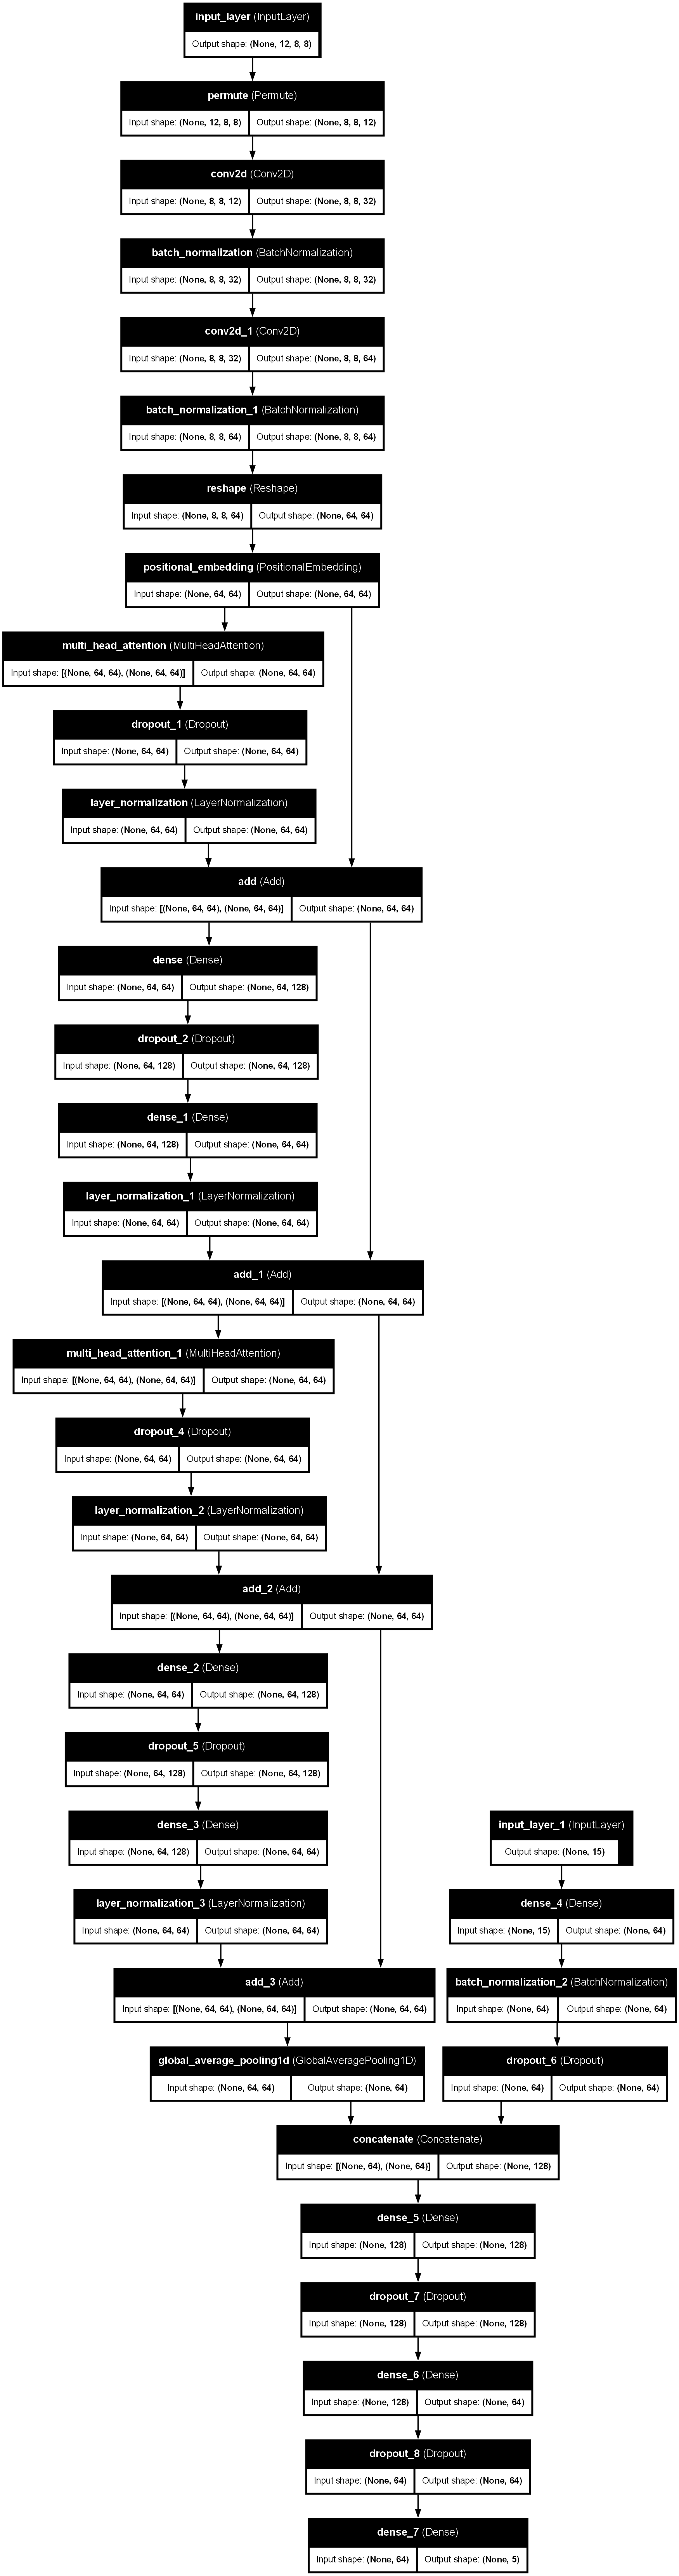

In [7]:


import tensorflow as tf

tf.keras.backend.clear_session()

# ==========================================================
# IMPORTS
# ==========================================================

import numpy as np

from tensorflow.keras import (
    layers,
    models,
    regularizers
)

from tensorflow.keras.utils import (
    plot_model
)

from IPython.display import (
    Image,
    display
)

# ==========================================================
# DUMMY VALUES
# (ONLY FOR BUILDING SUMMARY/PLOT)
# ==========================================================

NUM_CLASSES = 5
SCALAR_FEATURES = 15

# ==========================================================
# POSITIONAL EMBEDDING LAYER
# ==========================================================

class PositionalEmbedding(
    layers.Layer
):

    def __init__(self, sequence_length, d_model):

        super().__init__()

        self.pos_embedding = layers.Embedding(
            input_dim=sequence_length,
            output_dim=d_model
        )

        self.sequence_length = sequence_length
        self.d_model = d_model

    def call(self, inputs):

        positions = tf.range(
            start=0,
            limit=self.sequence_length,
            delta=1
        )

        embedded_positions = self.pos_embedding(
            positions
        )

        return inputs + embedded_positions

# ==========================================================
# TRANSFORMER ENCODER
# ==========================================================

def transformer_encoder(
    inputs,
    head_size,
    num_heads,
    ff_dim,
    dropout=0.1
):

    # ------------------------------------------------------
    # MULTIHEAD ATTENTION
    # ------------------------------------------------------

    x = layers.MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(inputs, inputs)

    # ------------------------------------------------------

    x = layers.Dropout(dropout)(x)

    x = layers.LayerNormalization(
        epsilon=1e-6
    )(x)

    # ------------------------------------------------------
    # RESIDUAL CONNECTION
    # ------------------------------------------------------

    res = layers.Add()([
        x,
        inputs
    ])

    # ------------------------------------------------------
    # FEED FORWARD
    # ------------------------------------------------------

    x = layers.Dense(
        ff_dim,
        activation='swish'
    )(res)

    x = layers.Dropout(dropout)(x)

    x = layers.Dense(
        inputs.shape[-1]
    )(x)

    x = layers.LayerNormalization(
        epsilon=1e-6
    )(x)

    # ------------------------------------------------------
    # SECOND RESIDUAL
    # ------------------------------------------------------

    return layers.Add()([
        x,
        res
    ])

# ==========================================================
# BUILD MODEL
# ==========================================================

def build_model():

    # ======================================================
    # TENSOR INPUT
    # ======================================================

    tensor_input = layers.Input(
        shape=(12,8,8)
    )

    # ======================================================
    # PERMUTE
    # ======================================================

    x = layers.Permute(
        (2,3,1)
    )(tensor_input)

    # ======================================================
    # CNN BLOCK
    # ======================================================

    x = layers.Conv2D(
        32,
        (3,3),
        padding='same',
        activation='swish'
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(
        64,
        (3,3),
        padding='same',
        activation='swish'
    )(x)

    x = layers.BatchNormalization()(x)

    # ======================================================
    # RESHAPE
    # ======================================================

    x = layers.Reshape(
        (64,64)
    )(x)

    # ======================================================
    # POSITIONAL EMBEDDING
    # ======================================================

    x = PositionalEmbedding(
        sequence_length=64,
        d_model=64
    )(x)

    # ======================================================
    # TRANSFORMER BLOCK 1
    # ======================================================

    x = transformer_encoder(
        x,
        head_size=64,
        num_heads=4,
        ff_dim=128,
        dropout=0.1
    )

    # ======================================================
    # TRANSFORMER BLOCK 2
    # ======================================================

    x = transformer_encoder(
        x,
        head_size=64,
        num_heads=4,
        ff_dim=128,
        dropout=0.1
    )

    # ======================================================
    # GLOBAL AVERAGE POOLING
    # ======================================================

    x = layers.GlobalAveragePooling1D()(x)

    # ======================================================
    # SCALAR INPUT
    # ======================================================

    scalar_input = layers.Input(
        shape=(SCALAR_FEATURES,)
    )

    y = layers.Dense(
        64,
        activation='swish'
    )(scalar_input)

    y = layers.BatchNormalization()(y)

    y = layers.Dropout(0.2)(y)

    # ======================================================
    # CONCATENATION
    # ======================================================

    combined = layers.concatenate(
        [x, y]
    )

    # ======================================================
    # FINAL DENSE BLOCK
    # ======================================================

    z = layers.Dense(
        128,
        activation='swish',
        kernel_regularizer=regularizers.l2(0.001)
    )(combined)

    z = layers.Dropout(0.3)(z)

    z = layers.Dense(
        64,
        activation='swish'
    )(z)

    z = layers.Dropout(0.3)(z)

    output = layers.Dense(
        NUM_CLASSES,
        activation='softmax'
    )(z)

    # ======================================================
    # MODEL
    # ======================================================

    model = models.Model(

        inputs=[
            tensor_input,
            scalar_input
        ],

        outputs=output
    )

    return model

# ==========================================================
# BUILD MODEL
# ==========================================================

model = build_model()

# ==========================================================
# MODEL SUMMARY
# ==========================================================

model.summary()

# ==========================================================
# PLOT MODEL
# ==========================================================

plot_model(

    model,

    to_file="final_transformer_model_plot.png",

    show_shapes=True,

    show_dtype=False,

    show_layer_names=True,

    rankdir="TB",

    expand_nested=False,

    dpi=120
)

# ==========================================================
# DISPLAY MODEL IMAGE
# ==========================================================

display(
    Image(
        filename="final_transformer_model_plot.png"
    )
)



FULL TRANSFORMER MODEL SUMMARY



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                       ┃ Output Shape                   ┃              Param # ┃ Connected to        
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━
│ input_layer (InputLayer)           │ (None, 12, 8, 8)               │                    0 │ -                   
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ permute (Permute)                  │ (None, 8, 8, 12)               │                    0 │ input_layer[0][0]   
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ conv2d (Conv2D)                    │ (None, 8, 8, 32)               │                3,488 │ permute[0][0]       
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ batch_normalization                │ (None, 8, 8, 32)               │                  128 │ conv2d[0][0]        
│ (BatchNormalization)               │                                │                      │                     
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ conv2d_1 (Conv2D)                  │ (None, 8, 8, 64)               │               18,496 │ batch_normalization[
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ batch_normalization_1              │ (None, 8, 8, 64)               │                  256 │ conv2d_1[0][0]      
│ (BatchNormalization)               │                                │                      │                     
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ reshape (Reshape)                  │ (None, 64, 64)                 │                    0 │ batch_normalization_
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ positional_embedding               │ (None, 64, 64)                 │                4,096 │ reshape[0][0]       
│ (PositionalEmbedding)              │                                │                      │                     
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ multi_head_attention               │ (None, 64, 64)                 │               66,368 │ positional_embedding
│ (MultiHeadAttention)               │                                │                      │ positional_embedding
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ dropout_1 (Dropout)                │ (None, 64, 64)                 │                    0 │ multi_head_attention
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ layer_normalization                │ (None, 64, 64)                 │                  128 │ dropout_1[0][0]     
│ (LayerNormalization)               │                                │                      │                     
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ add (Add)                          │ (None, 64, 64)                 │                    0 │ layer_normalization[
│                                    │                                │                      │ positional_embedding
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ dense (Dense)                      │ (None, 64, 128)                │                8,320 │ add[0][0]           
├────────────────────────────────────┼──────────────────

 Total params: 219,237 (856.39 KB)

 Trainable params: 218,917 (855.14 KB)

 Non-trainable params: 320 (1.25 KB)


Summary table saved:
transformer_model_summary.txt

MODEL LAYERS TABLE

                  Layer Name              Layer Type      Output Shape  \
0                input_layer              InputLayer  (None, 12, 8, 8)   
1                    permute                 Permute  (None, 8, 8, 12)   
2                     conv2d                  Conv2D  (None, 8, 8, 32)   
3        batch_normalization      BatchNormalization  (None, 8, 8, 32)   
4                   conv2d_1                  Conv2D  (None, 8, 8, 64)   
5      batch_normalization_1      BatchNormalization  (None, 8, 8, 64)   
6                    reshape                 Reshape    (None, 64, 64)   
7       positional_embedding     PositionalEmbedding    (None, 64, 64)   
8       multi_head_attention      MultiHeadAttention    (None, 64, 64)   
9                  dropout_1                 Dropout    (None, 64, 64)   
10       layer_normalization      LayerNormalization    (None, 64, 64)   
11                       add           

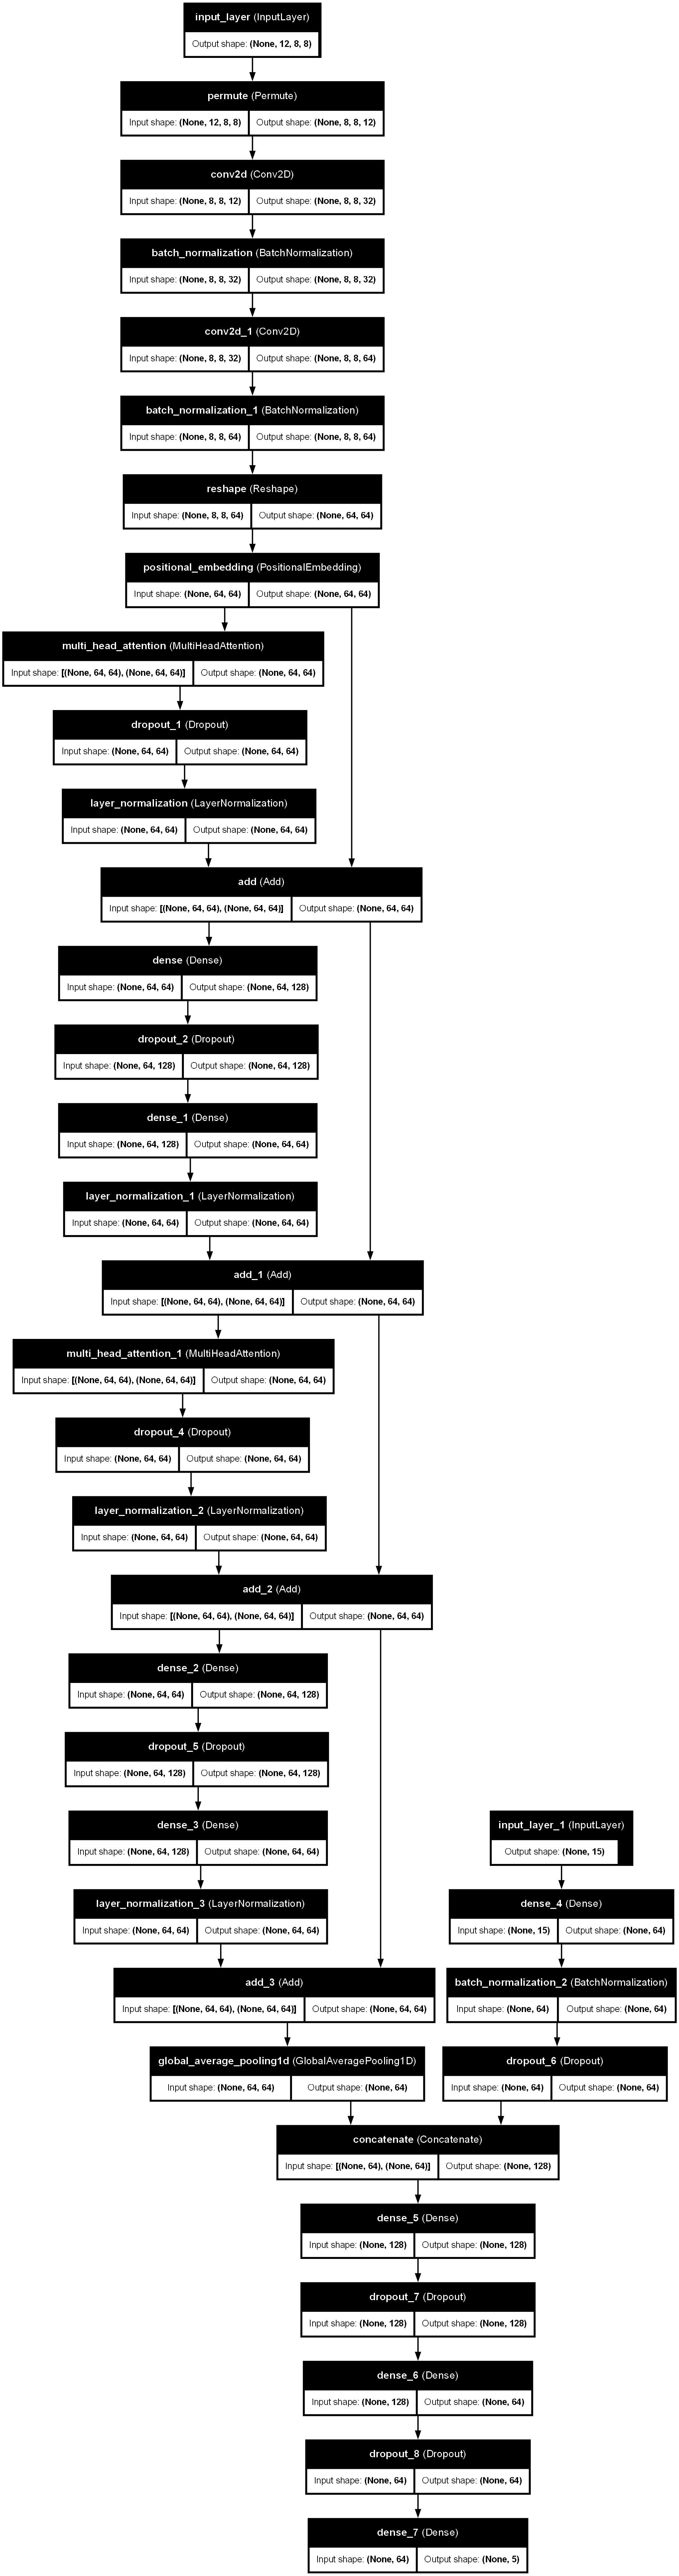


COMPLETE MODEL PIPELINE



12x8x8 Chess Tensor
        ↓
Permute Layer
        ↓
CNN Feature Extraction
(Conv2D → BN → Conv2D → BN)
        ↓
Reshape to 64x64 Sequence
        ↓
Positional Embedding
        ↓
Transformer Encoder Block 1
        ↓
Transformer Encoder Block 2
        ↓
Global Average Pooling
        ↓
64 Transformer Features

                +
        Scalar Features
                ↓
Scalar Dense Block
(Dense → BN → Dropout)
                ↓
64 Scalar Features

                ↓
Concatenation
(64 + 64 = 128 Features)
                ↓
Dense(128)
                ↓
Dropout
                ↓
Dense(64)
                ↓
Dropout
                ↓
Softmax Output
                ↓
Final Chess Move Prediction


PARAMETER STATISTICS

Total Parameters      : 219,237
Trainable Parameters  : 218,917
Non-Trainable Params  : 320

FILES GENERATED

1. transformer_model_summary.txt
2. transformer_model_layers.csv
3. final_transformer_model_plot.png


In [1]:
# ==========================================================
# RESET TENSORFLOW SESSION
# IMPORTANT:
# Ensures EXACT SAME layer numbering
# ==========================================================

import tensorflow as tf

tf.keras.backend.clear_session()

# ==========================================================
# IMPORTS
# ==========================================================

import numpy as np
import pandas as pd

from tensorflow.keras import (
    layers,
    models,
    regularizers
)

from tensorflow.keras.utils import (
    plot_model
)

from IPython.display import (
    Image,
    display
)

# ==========================================================
# DUMMY SETTINGS
# ONLY FOR SUMMARY + PLOT
# ==========================================================

NUM_CLASSES = 5
SCALAR_FEATURES = 15

# ==========================================================
# POSITIONAL EMBEDDING LAYER
# ==========================================================

class PositionalEmbedding(
    layers.Layer
):

    def __init__(
        self,
        sequence_length,
        d_model
    ):

        super().__init__()

        self.pos_embedding = layers.Embedding(
            input_dim=sequence_length,
            output_dim=d_model
        )

        self.sequence_length = sequence_length
        self.d_model = d_model

    def call(self, inputs):

        positions = tf.range(
            start=0,
            limit=self.sequence_length,
            delta=1
        )

        embedded_positions = self.pos_embedding(
            positions
        )

        return inputs + embedded_positions

# ==========================================================
# TRANSFORMER ENCODER
# ==========================================================

def transformer_encoder(
    inputs,
    head_size,
    num_heads,
    ff_dim,
    dropout=0.1
):

    # ======================================================
    # MULTIHEAD ATTENTION
    # ======================================================

    x = layers.MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(inputs, inputs)

    # ======================================================

    x = layers.Dropout(
        dropout
    )(x)

    x = layers.LayerNormalization(
        epsilon=1e-6
    )(x)

    # ======================================================
    # FIRST RESIDUAL CONNECTION
    # ======================================================

    res = layers.Add()([
        x,
        inputs
    ])

    # ======================================================
    # FEED FORWARD NETWORK
    # ======================================================

    x = layers.Dense(
        ff_dim,
        activation='swish'
    )(res)

    x = layers.Dropout(
        dropout
    )(x)

    x = layers.Dense(
        inputs.shape[-1]
    )(x)

    x = layers.LayerNormalization(
        epsilon=1e-6
    )(x)

    # ======================================================
    # SECOND RESIDUAL CONNECTION
    # ======================================================

    return layers.Add()([
        x,
        res
    ])

# ==========================================================
# BUILD MODEL
# ==========================================================

def build_model():

    # ======================================================
    # TENSOR INPUT
    # ======================================================

    tensor_input = layers.Input(
        shape=(12,8,8)
    )

    # ======================================================
    # PERMUTE
    # ======================================================

    x = layers.Permute(
        (2,3,1)
    )(tensor_input)

    # ======================================================
    # CNN BLOCK
    # ======================================================

    x = layers.Conv2D(
        32,
        (3,3),
        padding='same',
        activation='swish'
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(
        64,
        (3,3),
        padding='same',
        activation='swish'
    )(x)

    x = layers.BatchNormalization()(x)

    # ======================================================
    # RESHAPE TO SEQUENCE
    # ======================================================

    x = layers.Reshape(
        (64,64)
    )(x)

    # ======================================================
    # POSITIONAL EMBEDDING
    # ======================================================

    x = PositionalEmbedding(
        sequence_length=64,
        d_model=64
    )(x)

    # ======================================================
    # TRANSFORMER BLOCK 1
    # ======================================================

    x = transformer_encoder(
        x,
        head_size=64,
        num_heads=4,
        ff_dim=128,
        dropout=0.1
    )

    # ======================================================
    # TRANSFORMER BLOCK 2
    # ======================================================

    x = transformer_encoder(
        x,
        head_size=64,
        num_heads=4,
        ff_dim=128,
        dropout=0.1
    )

    # ======================================================
    # GLOBAL AVERAGE POOLING
    # ======================================================

    x = layers.GlobalAveragePooling1D()(x)

    # ======================================================
    # SCALAR INPUT
    # ======================================================

    scalar_input = layers.Input(
        shape=(SCALAR_FEATURES,)
    )

    y = layers.Dense(
        64,
        activation='swish'
    )(scalar_input)

    y = layers.BatchNormalization()(y)

    y = layers.Dropout(0.2)(y)

    # ======================================================
    # CONCATENATE
    # ======================================================

    combined = layers.concatenate(
        [x, y]
    )

    # ======================================================
    # FINAL DENSE BLOCK
    # ======================================================

    z = layers.Dense(
        128,
        activation='swish',
        kernel_regularizer=regularizers.l2(0.001)
    )(combined)

    z = layers.Dropout(0.3)(z)

    z = layers.Dense(
        64,
        activation='swish'
    )(z)

    z = layers.Dropout(0.3)(z)

    output = layers.Dense(
        NUM_CLASSES,
        activation='softmax'
    )(z)

    # ======================================================
    # MODEL
    # ======================================================

    model = models.Model(

        inputs=[
            tensor_input,
            scalar_input
        ],

        outputs=output
    )

    return model

# ==========================================================
# BUILD MODEL
# ==========================================================

model = build_model()

# ==========================================================
# FULL MODEL SUMMARY
# ==========================================================

print("\n====================================================")
print("FULL TRANSFORMER MODEL SUMMARY")
print("====================================================\n")

model.summary(
    line_length=140,
    expand_nested=True,
    show_trainable=True
)

# ==========================================================
# SAVE SUMMARY TABLE
# ==========================================================

summary_list = []

model.summary(
    print_fn=lambda x: summary_list.append(x)
)

summary_text = "\n".join(summary_list)

with open(
    "transformer_model_summary.txt",
    "w"
) as f:

    f.write(summary_text)

print("\nSummary table saved:")
print("transformer_model_summary.txt")

# ==========================================================
# CREATE SUMMARY DATAFRAME
# ==========================================================

rows = []

for layer in model.layers:

    rows.append({

        "Layer Name": layer.name,

        "Layer Type": layer.__class__.__name__,

        "Output Shape": str(layer.output.shape),

        "Parameters": layer.count_params()
    })

summary_df = pd.DataFrame(rows)

# ==========================================================
# DISPLAY TABLE
# ==========================================================

print("\n====================================================")
print("MODEL LAYERS TABLE")
print("====================================================\n")

print(summary_df)

# ==========================================================
# SAVE TABLE CSV
# ==========================================================

summary_df.to_csv(
    "transformer_model_layers.csv",
    index=False
)

print("\nLayer table saved:")
print("transformer_model_layers.csv")

# ==========================================================
# MODEL PLOT
# ==========================================================

plot_model(

    model,

    to_file="final_transformer_model_plot.png",

    show_shapes=True,

    show_dtype=False,

    show_layer_names=True,

    rankdir="TB",

    expand_nested=False,

    dpi=140
)

print("\nModel plot saved:")
print("final_transformer_model_plot.png")

# ==========================================================
# DISPLAY MODEL PLOT
# ==========================================================

display(
    Image(
        filename="final_transformer_model_plot.png"
    )
)

# ==========================================================
# FINAL PIPELINE
# ==========================================================

print("\n====================================================")
print("COMPLETE MODEL PIPELINE")
print("====================================================\n")

print("""

12x8x8 Chess Tensor
        ↓
Permute Layer
        ↓
CNN Feature Extraction
(Conv2D → BN → Conv2D → BN)
        ↓
Reshape to 64x64 Sequence
        ↓
Positional Embedding
        ↓
Transformer Encoder Block 1
        ↓
Transformer Encoder Block 2
        ↓
Global Average Pooling
        ↓
64 Transformer Features

                +
        Scalar Features
                ↓
Scalar Dense Block
(Dense → BN → Dropout)
                ↓
64 Scalar Features

                ↓
Concatenation
(64 + 64 = 128 Features)
                ↓
Dense(128)
                ↓
Dropout
                ↓
Dense(64)
                ↓
Dropout
                ↓
Softmax Output
                ↓
Final Chess Move Prediction

""")

# ==========================================================
# PARAMETER COUNTS
# ==========================================================

print("====================================================")
print("PARAMETER STATISTICS")
print("====================================================\n")

print(f"Total Parameters      : {model.count_params():,}")

trainable_params = np.sum([
    np.prod(v.shape)
    for v in model.trainable_weights
])

non_trainable_params = np.sum([
    np.prod(v.shape)
    for v in model.non_trainable_weights
])

print(f"Trainable Parameters  : {trainable_params:,}")
print(f"Non-Trainable Params  : {non_trainable_params:,}")

print("\n====================================================")
print("FILES GENERATED")
print("====================================================\n")

print("1. transformer_model_summary.txt")
print("2. transformer_model_layers.csv")
print("3. final_transformer_model_plot.png")